In [10]:
import numpy as np
import pandas as pd
import os
import re
import glob
from pathlib import Path
import matplotlib.pyplot as plt
import seaborn

# Karambola

In [2]:
# Define datasets, center types, resolutions, and subfolders
datasets = ['adrenal3d']
# center_types = ['com', 'cos', 'coc', 'cov']
channels = ["28", "64"]
subfolders = ['train', 'test', 'validation']

# Base paths
base_results_path = '../../data/results/medmnist/randomly_rotated_v_120182025'
base_output_path = '../../data/karambola_results/medmnist'

In [3]:
 # Function to calculate beta value (min/max of eigenvalues)
def calculate_beta(eigenvalues):
    return min(np.abs(eigenvalues)) / max(np.abs(eigenvalues))
def round_floats(df, decimals=5):
    float_cols = df.select_dtypes(include='float').columns
    df[float_cols] = df[float_cols].round(decimals)
    df[float_cols] = df[float_cols].replace(0.0, 1e-5)
    return df
# def process_symmetric_columns(dataset, res, overwrite=True):
def process_symmetric_columns(df):

    """
    Process a DataFrame to identify and drop redundant symmetric columns based on a pattern.
    
    Parameters:
    - dataset (str): Name of the dataset (e.g., 'adrenal3d', 'adrenal3d').
    - res (str): Resolution (e.g., '28', '64').
    - overwrite (bool): If True, overwrite the original CSV file. Default is True.
    
    Returns:
    - pd.DataFrame: Processed DataFrame with redundant columns dropped.
    """
    pattern = re.compile(r"^(w\d{3})_(\d)(\d)$")  # matches like w020_12, w102_21, etc.
    
    # Construct file path
    # path = f"./data/medmnist/{dataset}/{dataset}_{res}/minkowski_tensors_with_eigen_vals.csv"
    # df = pd.read_csv(path)
    # print(f"\n{dataset}_{res} — starting with {len(df.columns)} columns")
    print(f"Starting with {len(df.columns)} columns")


    # Identify symmetric column pairs
    pairs = []
    for col in df.columns:
        m = pattern.match(col)
        if m:
            tensor, i, j = m.groups()
            symmetric_col = f"{tensor}_{j}{i}"
            if (
                symmetric_col in df.columns 
                and (col, symmetric_col) not in pairs 
                and (symmetric_col, col) not in pairs
            ):
                pairs.append((col, symmetric_col))

    # Check for redundant columns
    cols_to_drop = []
    for col1, col2 in pairs:
        m1 = pattern.match(col1)
        if not m1:
            continue
        _, i, j = m1.groups()

        # Skip diagonal entries (i == j)
        if i == j:
            continue

        all_equal = (df[col1] == df[col2]).all()
        if all_equal:
            print(f"{col1} == {col2} for all rows ✅ — dropping {col2}")
            cols_to_drop.append(col2)
        else:
            diff_rows = (df[col1] != df[col2]).sum()
            print(f"{col1} != {col2} in {diff_rows} rows ❌")

    # Drop redundant columns
    df = df.drop(columns=cols_to_drop)
    print(f"After drop: {len(df.columns)} columns remain")
    
    # Optionally overwrite the original file
    # if overwrite:
    #     df.to_csv(path, index=False)
    
    return df



In [42]:
# Process each dataset, center type, and resolution
for dataset in datasets:
    for channel in channels:
        # Define paths
        parent_directory_path = os.path.join(base_results_path, f'{dataset}', f'{dataset}_{channel}')
        output_directory = os.path.join(base_output_path, f'{dataset}', f'{dataset}_{channel}')
        
        # Check if input directory exists
        if not os.path.exists(parent_directory_path):
            print(f'Skipping {channel}: Directory {parent_directory_path} does not exist')
            continue

        # Initialize results dictionary for scalar tensors
        results = {
            'image_num': [],
            'label': [],
            'subfolder': [],
            'w000': [], 'w100': [], 'w200': [], 'w300': [],
            'w010_0': [], 'w010_1': [], 'w010_2': [],
            'w110_0': [], 'w110_1': [], 'w110_2': [],
            'w210_0': [], 'w210_1': [], 'w210_2': [],
            'w310_0': [], 'w310_1': [], 'w310_2': [],
            'w020_00': [], 'w020_01': [], 'w020_02': [],
            'w020_10': [], 'w020_11': [], 'w020_12': [],
            'w020_20': [], 'w020_21': [], 'w020_22': [],
            'w120_00': [], 'w120_01': [], 'w120_02': [],
            'w120_10': [], 'w120_11': [], 'w120_12': [],
            'w120_20': [], 'w120_21': [], 'w120_22': [],
            'w220_00': [], 'w220_01': [], 'w220_02': [],
            'w220_10': [], 'w220_11': [], 'w220_12': [],
            'w220_20': [], 'w220_21': [], 'w220_22': [],
            'w320_00': [], 'w320_01': [], 'w320_02': [],
            'w320_10': [], 'w320_11': [], 'w320_12': [],
            'w320_20': [], 'w320_21': [], 'w320_22': [],
            'w102_00': [], 'w102_01': [], 'w102_02': [],
            'w102_10': [], 'w102_11': [], 'w102_12': [],
            'w102_20': [], 'w102_21': [], 'w102_22': [],
            'w202_00': [], 'w202_01': [], 'w202_02': [],
            'w202_10': [], 'w202_11': [], 'w202_12': [],
            'w202_20': [], 'w202_21': [], 'w202_22': [],
            'beta_w020': [], 'beta_w102': [], 'beta_w120': [],
            'beta_w202': [], 'beta_w220': [], 'beta_w320': [],
            'w020_EVal1': [], 'w020_EVal2': [], 'w020_EVal3': [],
            'w102_EVal1': [], 'w102_EVal2': [], 'w102_EVal3': [],
            'w120_EVal1': [], 'w120_EVal2': [], 'w120_EVal3': [],
            'w202_EVal1': [], 'w202_EVal2': [], 'w202_EVal3': [],
            'w220_EVal1': [], 'w220_EVal2': [], 'w220_EVal3': [],
            'w320_EVal1': [], 'w320_EVal2': [], 'w320_EVal3': []
        }

        # Process each subfolder
        for subfolder in subfolders:
            subfolder_path = os.path.join(parent_directory_path, subfolder)
            if not os.path.exists(subfolder_path):
                print(f'Skipping subfolder {subfolder} in {channel}: Directory does not exist')
                continue

            # Find all folders within the subfolder
            folder_pattern = os.path.join(subfolder_path, '*')
            folders = glob.glob(folder_pattern)

            for folder in folders:
                if not os.path.isdir(folder):
                    continue

                # Extract folder name components
                folder_name = os.path.basename(folder)
                try:
                    folder_id, image_id, label_str, label = folder_name.split('_')
                    image_id = str(image_id) # CellId includes string. 
                    label = int(label)
                except ValueError:
                    print(f'Skipping folder {folder_name} in {subfolder}: Invalid name format')
                    continue

                # Initialize data for this folder
                folder_data = {
                    'w000': None, 'w100': None, 'w200': None, 'w300': None,
                    'w010': [None, None, None], 'w110': [None, None, None],
                    'w210': [None, None, None], 'w310': [None, None, None],
                    'w020': [[None, None, None], [None, None, None], [None, None, None]],
                    'w120': [[None, None, None], [None, None, None], [None, None, None]],
                    'w220': [[None, None, None], [None, None, None], [None, None, None]],
                    'w320': [[None, None, None], [None, None, None], [None, None, None]],
                    'w102': [[None, None, None], [None, None, None], [None, None, None]],
                    'w202': [[None, None, None], [None, None, None], [None, None, None]],
                    'w020_eig': [None, None, None], 'w102_eig': [None, None, None],
                    'w120_eig': [None, None, None], 'w202_eig': [None, None, None],
                    'w220_eig': [None, None, None], 'w320_eig': [None, None, None]
                }

                # Process scalar tensors (w000_w100_w200_w300)
                file_path = os.path.join(folder, 'w000_w100_w200_w300')
                if os.path.exists(file_path):
                    with open(file_path, 'r') as file:
                        for line in file:
                            if line.startswith('#'):
                                continue
                            columns = line.split()
                            if len(columns) > 3:
                                value = float(columns[1])
                                name = columns[2]
                                if name in folder_data:
                                    folder_data[name] = value

                # Process vector tensors (w010_w110_w210_w310)
                file_path = os.path.join(folder, 'w010_w110_w210_w310')
                if os.path.exists(file_path):
                    with open(file_path, 'r') as file:
                        for line in file:
                            if line.startswith('#'):
                                continue
                            columns = line.split()
                            if len(columns) > 5:
                                vx, vy, vz = float(columns[1]), float(columns[2]), float(columns[3])
                                name = columns[4]
                                if name in folder_data:
                                    folder_data[name] = [vx, vy, vz]

                # Process matrix tensors (w020, w120, w220, w320, w102, w202)
                for tensor in ['w020', 'w120', 'w220', 'w320', 'w102', 'w202']:
                    file_path = os.path.join(folder, tensor)
                    if os.path.exists(file_path):
                        with open(file_path, 'r') as file:
                            for line in file:
                                if line.startswith('#'):
                                    continue
                                columns = line.split()
                                if len(columns) > 10:
                                    m00 = float(columns[1])
                                    m01 = float(columns[2])
                                    m02 = float(columns[3])
                                    m10 = float(columns[4])
                                    m11 = float(columns[5])
                                    m12 = float(columns[6])
                                    m20 = float(columns[7])
                                    m21 = float(columns[8])
                                    m22 = float(columns[9])
                                    name = columns[10]
                                    if name == tensor:
                                        folder_data[name] = [[m00, m01, m02], [m10, m11, m12], [m20, m21, m22]]

                # Process eigenvalue files
                for eigsys_file in ['w020_eigsys', 'w102_eigsys', 'w120_eigsys', 'w202_eigsys', 'w220_eigsys', 'w320_eigsys']:
                    file_path = os.path.join(folder, eigsys_file)
                    if os.path.exists(file_path):
                        with open(file_path, 'r') as file:
                            for line in file:
                                if line.startswith('#') or 'ALL' not in line:
                                    continue
                                parts = line.split()
                                EVal1 = float(parts[1])
                                EVal2 = float(parts[5])
                                EVal3 = float(parts[9])
                                eigenvalues = sorted([EVal1, EVal2, EVal3])  # sort here
                                folder_data[eigsys_file.split('_')[0] + '_eig'] = eigenvalues

                # Append data to results
                results['image_num'].append(image_id)
                results['label'].append(label)
                results['subfolder'].append(subfolder)
                for key in ['w000', 'w100', 'w200', 'w300']:
                    results[key].append(folder_data[key])
                for key in ['w010', 'w110', 'w210', 'w310']:
                    for i in range(3):
                        results[f'{key}_{i}'].append(folder_data[key][i])
                for key in ['w020', 'w120', 'w220', 'w320', 'w102', 'w202']:
                    for i in range(3):
                        for j in range(3):
                            results[f'{key}_{i}{j}'].append(folder_data[key][i][j])
                for key in ['w020', 'w102', 'w120', 'w202', 'w220', 'w320']:
                    eigenvalues = folder_data[key + '_eig']
                    results[f'beta_{key}'].append(calculate_beta(eigenvalues) if all(v is not None for v in eigenvalues) else None)
                    for i, eval_name in enumerate(['EVal1', 'EVal2', 'EVal3']):
                        results[f'{key}_{eval_name}'].append(eigenvalues[i])

        # Create DataFrame
        df = pd.DataFrame(results)
        df = round_floats(df)
        df = process_symmetric_columns(df)


        # Save to CSV
        df_path = Path(os.path.join(output_directory, 'rotated_v_12182025_adrenal3d_minkowski_tensors_with_eigen_vals.csv'))
        df_path.parent.mkdir(parents=True, exist_ok=True)
        df.to_csv(df_path, index=False)
        print(f'Saved DataFrame to {df_path}')

Starting with 97 columns
w020_01 == w020_10 for all rows ✅ — dropping w020_10
w020_02 == w020_20 for all rows ✅ — dropping w020_20
w020_12 == w020_21 for all rows ✅ — dropping w020_21
w120_01 == w120_10 for all rows ✅ — dropping w120_10
w120_02 == w120_20 for all rows ✅ — dropping w120_20
w120_12 == w120_21 for all rows ✅ — dropping w120_21
w220_01 == w220_10 for all rows ✅ — dropping w220_10
w220_02 == w220_20 for all rows ✅ — dropping w220_20
w220_12 == w220_21 for all rows ✅ — dropping w220_21
w320_01 == w320_10 for all rows ✅ — dropping w320_10
w320_02 == w320_20 for all rows ✅ — dropping w320_20
w320_12 == w320_21 for all rows ✅ — dropping w320_21
w102_01 == w102_10 for all rows ✅ — dropping w102_10
w102_02 == w102_20 for all rows ✅ — dropping w102_20
w102_12 == w102_21 for all rows ✅ — dropping w102_21
w202_01 == w202_10 for all rows ✅ — dropping w202_10
w202_02 == w202_20 for all rows ✅ — dropping w202_20
w202_12 == w202_21 for all rows ✅ — dropping w202_21
After drop: 79 column

Time taken: 172 seconds for karambola and 5.1 seconds for reading and writing

# Results using pykarambola

In [4]:
import pykarambola

In [5]:
# what not add to the package?
def arrays_from_triangulation(tri):
    """Extract vertex/face/label numpy arrays from a Triangulation object."""
    nv, nt = tri.n_vertices(), tri.n_triangles()
    verts = np.array([tri.get_pos_of_vertex(i) for i in range(nv)], dtype=np.float64)
    faces = np.array(
        [[tri.ith_vertex_of_triangle(j, i) for i in range(3)] for j in range(nt)],
        dtype=np.int64,
    )
    labels = np.array([tri.label_of_triangle(j) for j in range(nt)], dtype=np.int64)
    return verts, faces, labels

In [6]:
base_input_path = '../../data/input_files/medmnist/randomly_rotated_v_120182025'
tensor_keys = ['w020', 'w120', 'w220', 'w320', 'w102', 'w202']
vector_keys = ['w010', 'w110', 'w210', 'w310']

records = []

In [46]:
for dataset in datasets:
    for channel in channels:        # Define paths
        parent_directory_path = os.path.join(base_input_path, f'{dataset}', f'{dataset}_{channel}')
        output_directory = os.path.join(base_output_path, f'{dataset}', f'{dataset}_{channel}')
        
        # Check if input directory exists
        if not os.path.exists(parent_directory_path):
            print(f'Skipping {channel}: Directory {parent_directory_path} does not exist')
            continue


        # Process each subfolder
        for subfolder in subfolders:
            subfolder_path = os.path.join(parent_directory_path, subfolder)
            if not os.path.exists(subfolder_path):
                print(f'Skipping subfolder {subfolder} in {channel}: Directory does not exist')
                continue

            files = glob.glob(os.path.join(subfolder_path, '*.off'))
            print(f'Found {len(files)} .off files in {subfolder} of {channel}')

            for file in files:
                file_name = os.path.basename(file)
                try:
                    file_name = file_name.replace('.off', '')
                    folder_id, image_id, label_str, label = file_name.split('_')
                    image_id = str(image_id) # CellId includes string. 
                    label = int(label)
                    # print(f'Processing file: {file_name} — image_id: {image_id}, label: {label}')
                except ValueError:
                    print(f'Skipping file {file_name} in {subfolder}: Invalid name format')
                    continue

                tri = pykarambola.parse_off_file(file)
                poly_verts, poly_faces, _ = arrays_from_triangulation(tri)
                result = pykarambola.minkowski_functionals(poly_verts, poly_faces)

                row = {}
                row['image_num']    = image_id
                row['label'] = label
                row['subfolder']    = subfolder
                # print(row['label'])
                # break

                # Scalars
                row['w000'] = result['w000']
                row['w100'] = result['w100']
                row['w200'] = result['w200']
                row['w300'] = result['w300']

                # Vectors — w010, w110, w210, w310
                for vkey in vector_keys:
                    vec = result[vkey]
                    row[f'{vkey}_0'] = vec[0]
                    row[f'{vkey}_1'] = vec[1]
                    row[f'{vkey}_2'] = vec[2]

                # Tensors — upper triangle only (symmetric): 00, 01, 02, 11, 12, 22
                for tkey in tensor_keys:
                    mat = result[tkey]
                    row[f'{tkey}_00'] = mat[0, 0]
                    row[f'{tkey}_01'] = mat[0, 1]
                    row[f'{tkey}_02'] = mat[0, 2]
                    row[f'{tkey}_11'] = mat[1, 1]
                    row[f'{tkey}_12'] = mat[1, 2]
                    row[f'{tkey}_22'] = mat[2, 2]

                # Beta (anisotropy) and eigenvalues
                for tkey in tensor_keys:
                    eigvals = sorted(result[f'{tkey}_eigvals'])  # sort here
                    row[f'beta_{tkey}']    = calculate_beta(eigvals)
                    row[f'{tkey}_EVal1']   = eigvals[0]
                    row[f'{tkey}_EVal2']   = eigvals[1]
                    row[f'{tkey}_EVal3']   = eigvals[2]
                
                records.append(row)
                # print(records[-1])  # Print the most recently added record
                # break
                
                

        df_py = pd.DataFrame(records)
        # print(df_py.head())

        # Reorder columns to match target schema
        cols = [
            'image_num', 'label', 'subfolder',
            'w000', 'w100', 'w200', 'w300',
            'w010_0', 'w010_1', 'w010_2',
            'w110_0', 'w110_1', 'w110_2',
            'w210_0', 'w210_1', 'w210_2',
            'w310_0', 'w310_1', 'w310_2',
            'w020_00', 'w020_01', 'w020_02', 'w020_11', 'w020_12', 'w020_22',
            'w120_00', 'w120_01', 'w120_02', 'w120_11', 'w120_12', 'w120_22',
            'w220_00', 'w220_01', 'w220_02', 'w220_11', 'w220_12', 'w220_22',
            'w320_00', 'w320_01', 'w320_02', 'w320_11', 'w320_12', 'w320_22',
            'w102_00', 'w102_01', 'w102_02', 'w102_11', 'w102_12', 'w102_22',
            'w202_00', 'w202_01', 'w202_02', 'w202_11', 'w202_12', 'w202_22',
            'beta_w020', 'beta_w102', 'beta_w120', 'beta_w202', 'beta_w220', 'beta_w320',
            'w020_EVal1', 'w020_EVal2', 'w020_EVal3',
            'w102_EVal1', 'w102_EVal2', 'w102_EVal3',
            'w120_EVal1', 'w120_EVal2', 'w120_EVal3',
            'w202_EVal1', 'w202_EVal2', 'w202_EVal3',
            'w220_EVal1', 'w220_EVal2', 'w220_EVal3',
            'w320_EVal1', 'w320_EVal2', 'w320_EVal3',
        ]
        df_py = df_py[cols]
        df_py = round_floats(df_py)


        # Save
        output_path_csv = os.path.join(output_directory, 'rotated_v_12182025_adrenal3d_minkowski_tensors_with_eigen_vals_pykarambola.csv')
        df_py.to_csv(output_path_csv, index=False)
        print(f"Saved {len(df_py)} rows to {output_path_csv}")
        print(df_py.head())

Found 1188 .off files in train of 28
Found 298 .off files in test of 28
Found 98 .off files in validation of 28
Saved 1584 rows to ../../data/karambola_results/medmnist/adrenal3d/adrenal3d_28/rotated_v_12182025_adrenal3d_minkowski_tensors_with_eigen_vals_pykarambola.csv
  image_num  label subfolder       w000       w100      w200     w300  \
0       687      0     train  319.45833  183.08481  51.25388  0.00001   
1       977      0     train  546.95833  232.47106  45.37714  4.18879   
2       718      0     train  199.33333  125.05335  39.20021  4.18879   
3       248      0     train  507.66667  224.34875  47.35148  4.18879   
4      1115      1     train  468.00000  155.15951  34.79668  4.18879   

    w010_0   w010_1   w010_2  ...   w120_EVal3  w202_EVal1  w202_EVal2  \
0  0.00001  0.00001  0.00001  ...   5153.50398    13.79774    17.97550   
1  0.00001  0.00001  0.00001  ...  10812.70055    11.39416    15.50863   
2  0.00001  0.00001  0.00001  ...   4095.31187    10.50794    12.672

Time to run: 1 min 13.6 seconds or 73.6 seconds
second runtime: 1 m and 13.8 seconds

# Cython

In [9]:
base_input_path = '../../data/input_files/medmnist/randomly_rotated_v_120182025'
tensor_keys = ['w020', 'w120', 'w220', 'w320', 'w102', 'w202']
vector_keys = ['w010', 'w110', 'w210', 'w310']

records = []


In [10]:
for dataset in datasets:
    for channel in channels:        # Define paths
        parent_directory_path = os.path.join(base_input_path, f'{dataset}', f'{dataset}_{channel}')
        output_directory = os.path.join(base_output_path, f'{dataset}', f'{dataset}_{channel}')
        
        # Check if input directory exists
        if not os.path.exists(parent_directory_path):
            print(f'Skipping {channel}: Directory {parent_directory_path} does not exist')
            continue


        # Process each subfolder
        for subfolder in subfolders:
            subfolder_path = os.path.join(parent_directory_path, subfolder)
            if not os.path.exists(subfolder_path):
                print(f'Skipping subfolder {subfolder} in {channel}: Directory does not exist')
                continue

            files = glob.glob(os.path.join(subfolder_path, '*.off'))
            print(f'Found {len(files)} .off files in {subfolder} of {channel}')

            for file in files:
                file_name = os.path.basename(file)
                try:
                    file_name = file_name.replace('.off', '')
                    folder_id, image_id, label_str, label = file_name.split('_')
                    image_id = str(image_id) # CellId includes string. 
                    label = int(label)
                    # print(f'Processing file: {file_name} — image_id: {image_id}, label: {label}')
                except ValueError:
                    print(f'Skipping file {file_name} in {subfolder}: Invalid name format')
                    continue

                tri = pykarambola.parse_off_file(file)
                poly_verts, poly_faces, _ = arrays_from_triangulation(tri)
                result = pykarambola.minkowski_functionals(poly_verts, poly_faces)

                row = {}
                row['image_num']    = image_id
                row['label'] = label
                row['subfolder']    = subfolder
                # print(row['label'])
                # break

                # Scalars
                row['w000'] = result['w000']
                row['w100'] = result['w100']
                row['w200'] = result['w200']
                row['w300'] = result['w300']

                # Vectors — w010, w110, w210, w310
                for vkey in vector_keys:
                    vec = result[vkey]
                    row[f'{vkey}_0'] = vec[0]
                    row[f'{vkey}_1'] = vec[1]
                    row[f'{vkey}_2'] = vec[2]

                # Tensors — upper triangle only (symmetric): 00, 01, 02, 11, 12, 22
                for tkey in tensor_keys:
                    mat = result[tkey]
                    row[f'{tkey}_00'] = mat[0, 0]
                    row[f'{tkey}_01'] = mat[0, 1]
                    row[f'{tkey}_02'] = mat[0, 2]
                    row[f'{tkey}_11'] = mat[1, 1]
                    row[f'{tkey}_12'] = mat[1, 2]
                    row[f'{tkey}_22'] = mat[2, 2]

                # Beta (anisotropy) and eigenvalues
                for tkey in tensor_keys:
                    eigvals = sorted(result[f'{tkey}_eigvals'])  # sort here
                    row[f'beta_{tkey}']    = calculate_beta(eigvals)
                    row[f'{tkey}_EVal1']   = eigvals[0]
                    row[f'{tkey}_EVal2']   = eigvals[1]
                    row[f'{tkey}_EVal3']   = eigvals[2]
                
                records.append(row)
                # print(records[-1])  # Print the most recently added record
                # break
                
                

        df_py = pd.DataFrame(records)
        # print(df_py.head())

        # Reorder columns to match target schema
        cols = [
            'image_num', 'label', 'subfolder',
            'w000', 'w100', 'w200', 'w300',
            'w010_0', 'w010_1', 'w010_2',
            'w110_0', 'w110_1', 'w110_2',
            'w210_0', 'w210_1', 'w210_2',
            'w310_0', 'w310_1', 'w310_2',
            'w020_00', 'w020_01', 'w020_02', 'w020_11', 'w020_12', 'w020_22',
            'w120_00', 'w120_01', 'w120_02', 'w120_11', 'w120_12', 'w120_22',
            'w220_00', 'w220_01', 'w220_02', 'w220_11', 'w220_12', 'w220_22',
            'w320_00', 'w320_01', 'w320_02', 'w320_11', 'w320_12', 'w320_22',
            'w102_00', 'w102_01', 'w102_02', 'w102_11', 'w102_12', 'w102_22',
            'w202_00', 'w202_01', 'w202_02', 'w202_11', 'w202_12', 'w202_22',
            'beta_w020', 'beta_w102', 'beta_w120', 'beta_w202', 'beta_w220', 'beta_w320',
            'w020_EVal1', 'w020_EVal2', 'w020_EVal3',
            'w102_EVal1', 'w102_EVal2', 'w102_EVal3',
            'w120_EVal1', 'w120_EVal2', 'w120_EVal3',
            'w202_EVal1', 'w202_EVal2', 'w202_EVal3',
            'w220_EVal1', 'w220_EVal2', 'w220_EVal3',
            'w320_EVal1', 'w320_EVal2', 'w320_EVal3',
        ]
        df_py = df_py[cols]
        df_py = round_floats(df_py)


        # Save
        output_path_csv = os.path.join(output_directory, 'rotated_v_12182025_adrenal3d_minkowski_tensors_with_eigen_vals_pykarambola_cython.csv')
        df_py.to_csv(output_path_csv, index=False)
        print(f"Saved {len(df_py)} rows to {output_path_csv}")
        print(df_py.head())

Found 1188 .off files in train of 28
Found 298 .off files in test of 28
Found 98 .off files in validation of 28
Saved 1584 rows to ../../data/karambola_results/medmnist/adrenal3d/adrenal3d_28/rotated_v_12182025_adrenal3d_minkowski_tensors_with_eigen_vals_pykarambola_cython.csv
  image_num  label subfolder       w000       w100      w200     w300  \
0       687      0     train  319.45833  183.08481  51.25388  0.00001   
1       977      0     train  546.95833  232.47106  45.37714  4.18879   
2       718      0     train  199.33333  125.05335  39.20021  4.18879   
3       248      0     train  507.66667  224.34875  47.35148  4.18879   
4      1115      1     train  468.00000  155.15951  34.79668  4.18879   

    w010_0   w010_1   w010_2  ...   w120_EVal3  w202_EVal1  w202_EVal2  \
0  0.00001  0.00001  0.00001  ...   5153.50398    13.79774    17.97550   
1  0.00001  0.00001  0.00001  ...  10812.70055    11.39416    15.50863   
2  0.00001  0.00001  0.00001  ...   4095.31187    10.50794   

Time taken: 1m 14s = 74 seconds

Second runtime: 1m and 13.6 seconds

In [ ]:
# reading the vectorrized file
df_py = pd.read_csv('../../data/karambola_results/medmnist/adrenal3d/adrenal3d_28/rotated_v_12182025_adrenal3d_minkowski_tensors_with_eigen_vals_pykarambola.csv')
# df_py = pd.read_csv('../../data/karambola_results/medmnist/adrenal3d/adrenal3d_28/rotated_v_12182025_adrenal3d_minkowski_tensors_with_eigen_vals_pykarambola_cython.csv')
df = pd.read_csv('../../data/karambola_results/medmnist/adrenal3d/adrenal3d_28/rotated_v_12182025_adrenal3d_minkowski_tensors_with_eigen_vals.csv')


# Comparison time

In [14]:
# Merge on identifiers
df_merged = df.merge(df_py, on=['image_num', 'label', 'subfolder'], suffixes=('_k', '_py'))

# Numeric cols to compare
numeric_cols = df.select_dtypes(include='float').columns.tolist()

# Mean relative error per label
ABS_THRESHOLD = 1e-10
heatmap_data = []

for label in df_merged['label'].unique():
    mask = df_merged['label'] == label
    row = {'label': label}

    for col in numeric_cols:
        k_vals  = df_merged.loc[mask, f'{col}_k'].round(5)
        py_vals = df_merged.loc[mask, f'{col}_py'].round(5)

        abs_diff = (k_vals - py_vals).abs()
        denom = k_vals.abs()
        both_negligible = (k_vals.abs() < ABS_THRESHOLD) & (py_vals.abs() < ABS_THRESHOLD)
        denom[both_negligible] = np.nan
        denom = denom.replace(0, np.nan)

        rel_error = abs_diff / denom * 100
        row[col] = rel_error.mean()

    heatmap_data.append(row)

heatmap_df = pd.DataFrame(heatmap_data).set_index('label').fillna(0)

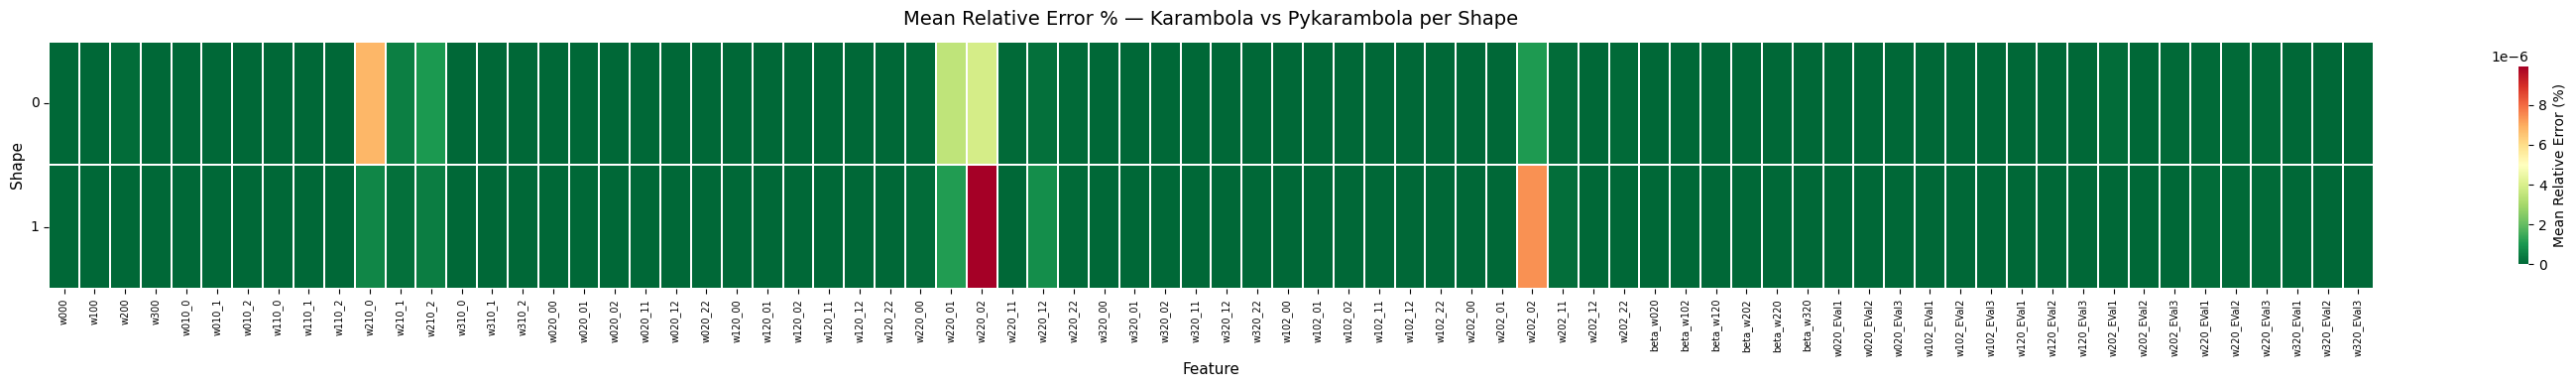

In [ ]:
import seaborn

# ── Step 5: Plot ──────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(30, 4))

seaborn.heatmap(
    heatmap_df,
    annot=False,            # no numbers printed inside cells
    cmap='RdYlGn_r',        # red = high error, green = low error
    linewidths=0.3,         # thin grid lines between cells
    ax=ax,
    cbar_kws={
        'label': 'Mean Relative Error (%)',   # legend label
        'shrink': 0.8,                         # slightly shrink the colorbar
    }
)

ax.set_title('Mean Relative Error % — Karambola vs Pykarambola per Shape',
             fontsize=14, pad=12)
ax.set_xlabel('Feature', fontsize=11)
ax.set_ylabel('Shape',   fontsize=11)
ax.tick_params(axis='x', rotation=90, labelsize=7)
ax.tick_params(axis='y', rotation=0,  labelsize=10)

plt.tight_layout()
plt.savefig('../plots/heatmap_relative_error_with_vectorization_adrenal3d.png', dpi=150, bbox_inches='tight')
plt.show()